In [115]:
import pandas as pd
import gridstatus

caiso = gridstatus.CAISO()

start = pd.Timestamp("2023-01-23", tz="US/Pacific")
end   = pd.Timestamp("2024-12-31", tz="US/Pacific")

parts = []
cur = start.normalize()  # force 00:00
while cur < end:
    nxt = min(cur + pd.Timedelta(days=7), end)
    try:
        part = caiso.get_lmp(
            date=cur,
            end=nxt,
            market="DAY_AHEAD_HOURLY",
            locations=["TH_NP15_GEN-APND"],   # if empty, try TH_NP15_GEN
        )
        if part is not None and len(part):
            parts.append(part)
    except Exception as e:
        print(f"Chunk failed: {cur} to {nxt} -> {e}")
    cur = nxt

lmp_chunked = pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()
print(lmp_chunked.head(), len(lmp_chunked))


lmp_df=lmp_chunked.copy()


# convert Time column to pandas datetime (timezone-aware)
lmp_df["Time"] = pd.to_datetime(lmp_df["Time"])


print(lmp_df.dtypes)
print(lmp_df.head())

2026-04-26 21:00:26 - DEBUG - Dataset config: {'query': {'path': 'SingleZip', 'resultformat': 6, 'queryname': 'PRC_LMP', 'version': 12}, 'params': {'market_run_id': 'DAM', 'node': None, 'grp_type': [None, 'ALL', 'ALL_APNODES']}}
2026-04-26 21:00:26 - INFO - Fetching URL: http://oasis.caiso.com/oasisapi/SingleZip?resultformat=6&queryname=PRC_LMP&version=12&market_run_id=DAM&node=TH_NP15_GEN-APND&startdatetime=20230123T08:00-0000&enddatetime=20230130T08:00-0000
2026-04-26 21:00:28 - DEBUG - Found 1 files: ['20230123_20230130_PRC_LMP_DAM_20260426_19_00_27_v12.csv']
2026-04-26 21:00:28 - DEBUG - Parsing file: 20230123_20230130_PRC_LMP_DAM_20260426_19_00_27_v12.csv
2026-04-26 21:00:33 - DEBUG - Dataset config: {'query': {'path': 'SingleZip', 'resultformat': 6, 'queryname': 'PRC_LMP', 'version': 12}, 'params': {'market_run_id': 'DAM', 'node': None, 'grp_type': [None, 'ALL', 'ALL_APNODES']}}
2026-04-26 21:00:33 - INFO - Fetching URL: http://oasis.caiso.com/oasisapi/SingleZip?resultformat=6&qu

                       Time            Interval Start  \
0 2023-01-23 00:00:00-08:00 2023-01-23 00:00:00-08:00   
1 2023-01-23 01:00:00-08:00 2023-01-23 01:00:00-08:00   
2 2023-01-23 02:00:00-08:00 2023-01-23 02:00:00-08:00   
3 2023-01-23 03:00:00-08:00 2023-01-23 03:00:00-08:00   
4 2023-01-23 04:00:00-08:00 2023-01-23 04:00:00-08:00   

               Interval End            Market          Location Location Type  \
0 2023-01-23 01:00:00-08:00  DAY_AHEAD_HOURLY  TH_NP15_GEN-APND   Trading Hub   
1 2023-01-23 02:00:00-08:00  DAY_AHEAD_HOURLY  TH_NP15_GEN-APND   Trading Hub   
2 2023-01-23 03:00:00-08:00  DAY_AHEAD_HOURLY  TH_NP15_GEN-APND   Trading Hub   
3 2023-01-23 04:00:00-08:00  DAY_AHEAD_HOURLY  TH_NP15_GEN-APND   Trading Hub   
4 2023-01-23 05:00:00-08:00  DAY_AHEAD_HOURLY  TH_NP15_GEN-APND   Trading Hub   

         LMP     Energy  Congestion     Loss  
0  129.61101  132.55370         0.0 -2.94269  
1  128.13030  131.13326         0.0 -3.00295  
2  122.70000  125.98829      

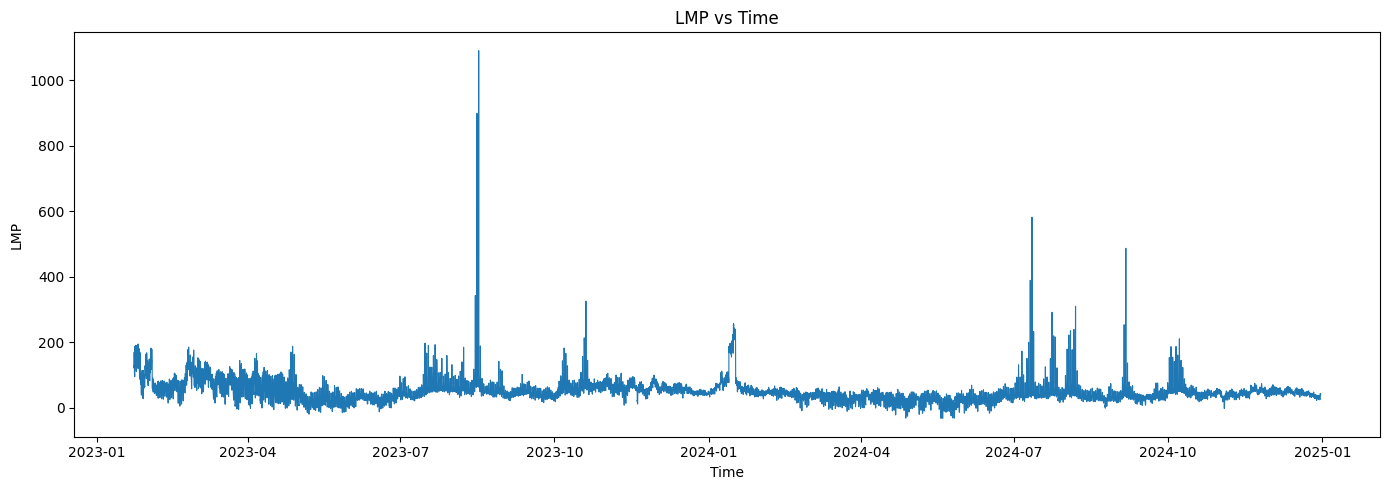

In [116]:
import matplotlib.pyplot as plt
import pandas as pd

# choose your time column in lmp_df (commonly "Time" or "Interval Start")
time_col = "Time"   # change if needed

lmp_df[time_col] = pd.to_datetime(lmp_df[time_col])
lmp_df = lmp_df.sort_values(time_col)

plt.figure(figsize=(14, 5))
plt.plot(lmp_df[time_col], lmp_df["LMP"], linewidth=0.8)
plt.xlabel(time_col)
plt.ylabel("LMP")
plt.title(f"LMP vs {time_col}")
plt.tight_layout()
plt.show()

In [117]:
import requests
import pandas as pd

# 1-day before weather forecasts
url = "https://previous-runs-api.open-meteo.com/v1/forecast"
params = {
    # 2107 Arbuckle, CA location
    "latitude": 38.9963,
    "longitude": -122.1341,
    "start_date": "2022-03-23",
    "end_date": "2024-10-31",
    # Use 'minutely_15' instead of 'hourly'
    "minutely_15": [
        "temperature_2m",
        "relative_humidity_2m",
        "dew_point_2m",
        "apparent_temperature",
        "wind_speed_10m",
        "wind_speed_80m",
        "wind_direction_10m",
        "wind_direction_80m",
        "wind_gusts_10m",
        "shortwave_radiation",
        "direct_radiation",
        "direct_normal_irradiance",
        "diffuse_radiation",
        "global_tilted_irradiance",
        "sunshine_duration",
        "precipitation",
        "snowfall",
        "rain",
        "cape",
        "visibility",
        "weather_code",
        "cloud_cover",
        "pressure_msl",
        "surface_pressure"
    ], 
    "models": "gfs_seamless",
    "previous_day": 1 
}

data = requests.get(url, params=params).json()
weather_df = pd.DataFrame(data['minutely_15']).rename(columns={"time": "measured_on"})

###########################
# Modify the file path used by pd.read_csv()


# meter_train date range: 2017-01-01 - 2023/11/09
meter_train = pd.read_csv("2107_meter_15m_data.csv")


# meter_2024 date range: 2024/01/01 - 2024/10/31
meter_2024 = pd.read_csv("2107_meter_15m_data_2024.csv")

# ensure same datetime type
weather_df["measured_on"] = pd.to_datetime(weather_df["measured_on"])
meter_train["measured_on"] = pd.to_datetime(meter_train["measured_on"])
meter_2024["measured_on"] = pd.to_datetime(meter_2024["measured_on"])


# df_train date range: 2022/03/23 - 2023/11/09
df_train = meter_train.merge(weather_df, on="measured_on", how="left").dropna()
# df_2024 date range: 2024/01/01 - 2024/10/31
df_2024 = meter_2024.merge(weather_df, on="measured_on", how="outer").dropna()

val_end = pd.Timestamp("2024-05-31 23:59:59")
# df_val date range: 2024-01-01 - 2024-05-31
df_val = df_2024[df_2024["measured_on"] <= val_end].copy()
# df_test date range: 2024-06-01 - 2024-10-31
df_test = df_2024[df_2024["measured_on"] > val_end].copy()

# Use df_train, df_val, df_test for train, validation(walk forward validation) and test.
print(df_train.head())

               measured_on  meter_revenue_grade_ac_output_meter_149578  \
182855 2022-03-23 00:00:00                                         0.0   
182856 2022-03-23 00:15:00                                         0.0   
182857 2022-03-23 00:30:00                                         0.0   
182858 2022-03-23 00:45:00                                         0.0   
182859 2022-03-23 01:00:00                                         0.0   

        temperature_2m  relative_humidity_2m  dew_point_2m  \
182855            29.2                  25.0           7.2   
182856            29.1                  25.0           7.1   
182857            28.8                  26.0           7.4   
182858            28.5                  27.0           7.7   
182859            28.1                  27.0           7.3   

        apparent_temperature  wind_speed_10m  wind_speed_80m  \
182855                  25.8            18.8            23.1   
182856                  25.8            17.5          

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

# Add baseline models to meter_train and meter_2024 to find out baseline MWOL


target = "meter_revenue_grade_ac_output_meter_149578"

meter_train["measured_on"] = pd.to_datetime(meter_train["measured_on"])
meter_train = meter_train.sort_values("measured_on").reset_index(drop=True)

steps_per_day = 96
lags = [steps_per_day * d for d in range(1, 4)]  # 1..3 days ago

meter_train["yhat_baseline"] = pd.concat(
    [meter_train[target].shift(l) for l in lags],
    axis=1
).mean(axis=1)

# keep only aligned columns
meter_train = meter_train[["measured_on", target, "yhat_baseline"]].copy()



# evaluate on rows where baseline exists
eval_df = meter_train.dropna(subset=[target, "yhat_baseline"])
mae = mean_absolute_error(eval_df[target], eval_df["yhat_baseline"])
rmse = np.sqrt(mean_squared_error(eval_df[target], eval_df["yhat_baseline"]))

#print(meter_train[["measured_on", target, "yhat_baseline"]].head(10))
print(f"Baseline model: train MAE:  {mae:.4f}")
print(f"Baseline model: train RMSE: {rmse:.4f}")

# Apply the same 7-day same-time baseline to meter_2024
target = "meter_revenue_grade_ac_output_meter_149578"

meter_2024["measured_on"] = pd.to_datetime(meter_2024["measured_on"])
meter_2024 = meter_2024.sort_values("measured_on").reset_index(drop=True)

steps_per_day = 96
lags = [steps_per_day * d for d in range(1, 4)]  # 1..3 days ago

meter_2024["yhat_baseline"] = pd.concat(
    [meter_2024[target].shift(l) for l in lags],
    axis=1
).mean(axis=1)


# Optional evaluation
eval_2024 = meter_2024.dropna(subset=[target, "yhat_baseline"])
mae_2024 = mean_absolute_error(eval_2024[target], eval_2024["yhat_baseline"])
rmse_2024 = np.sqrt(mean_squared_error(eval_2024[target], eval_2024["yhat_baseline"]))

#print(meter_2024[["measured_on", target, "yhat_baseline"]].head(20))
print(f"Baseline model: 2024 MAE:  {mae_2024:.4f}")
print(f"Baseline model: 2024 RMSE: {rmse_2024:.4f}")

Baseline model: train MAE:  39.5413
Baseline model: train RMSE: 88.4369
Baseline model: 2024 MAE:  37.0466
Baseline model: 2024 RMSE: 91.8166


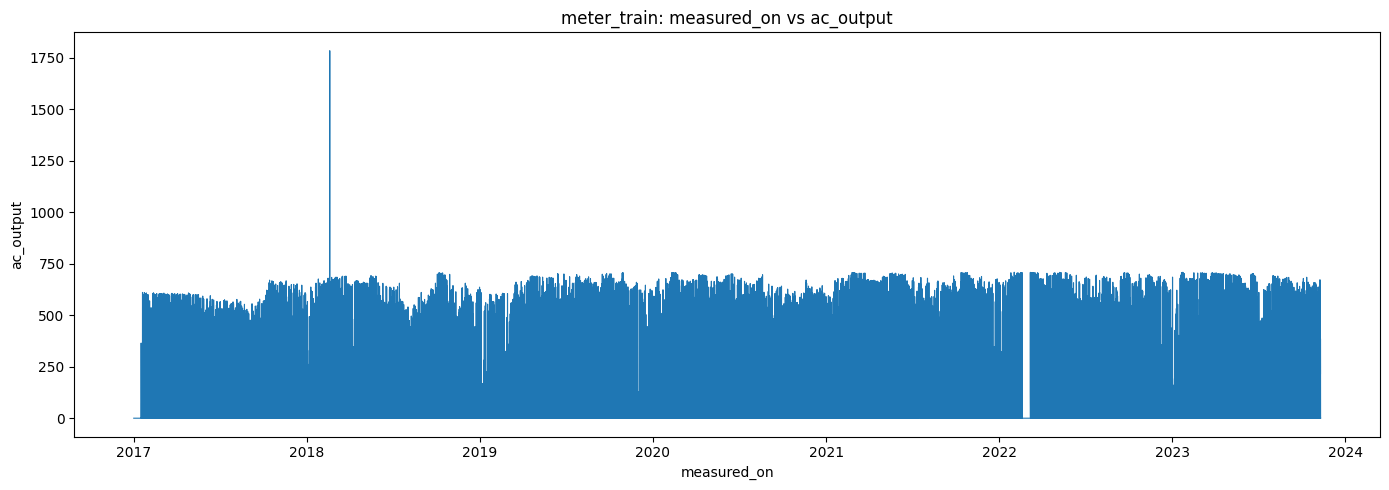

In [119]:
import matplotlib.pyplot as plt
import pandas as pd

target = "meter_revenue_grade_ac_output_meter_149578"

meter_train["measured_on"] = pd.to_datetime(meter_train["measured_on"])
meter_train = meter_train.sort_values("measured_on")

plt.figure(figsize=(14, 5))
plt.plot(meter_train["measured_on"], meter_train[target], linewidth=0.8)
plt.xlabel("measured_on")
plt.ylabel("ac_output")
plt.title("meter_train: measured_on vs ac_output")
plt.tight_layout()
plt.show()

Total MWOL: $5,694.38
Mean Daily MWOL: $19.64/day
Financial Efficiency: 87.83%


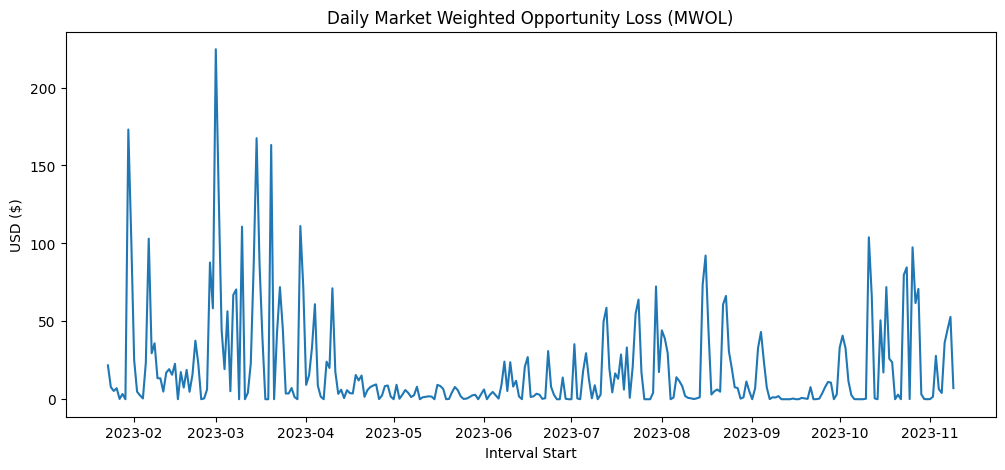

In [121]:
import pandas as pd
import numpy as np

def compute_market_weighted_loss(actuals_15min, preds_15min, lmp_df, time_col="measured_on"):
    # --- Nested Helper Function ---
    # Using your updated scale (0.001 * 0.25)
    def meter_to_hourly_scaled(df, time_col="measured_on", scale=0.001*0.25):
        df = df.copy()
        df[time_col] = pd.to_datetime(df[time_col]).dt.tz_localize(None) 
        df = df.sort_values(time_col)
        num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        
        df[num_cols] = df[num_cols] * scale
        # sum(min_count=1) returns NaN if all 4 15-min intervals are missing
        hourly_num = df.set_index(time_col)[num_cols].resample("1h").sum(min_count=1)
        return hourly_num.reset_index()

    # 1. Downsample to Hourly
    actuals_hourly = meter_to_hourly_scaled(actuals_15min, time_col=time_col)
    preds_hourly = meter_to_hourly_scaled(preds_15min, time_col=time_col)
    
    # 2. Align Data
    df = lmp_df.copy()
    df['Interval Start'] = pd.to_datetime(df['Interval Start']).dt.tz_localize(None)
    
    # Perform merges
    df = df.merge(actuals_hourly, left_on='Interval Start', right_on=time_col, how='left')
    df = df.merge(preds_hourly, left_on='Interval Start', right_on=time_col, how='left', suffixes=('_act', '_pred'))

    # --- CRITICAL CHANGE: DROP ROWS WITH MISSING DATA ---
    act_col = [c for c in actuals_hourly.columns if c != time_col][0]
    pred_col = [c for c in preds_hourly.columns if c != time_col][0]
    
    # Only proceed with rows where LMP, Actuals, and Predictions all exist
    # This ensures your financial metrics aren't skewed by 'ghost' data
    df = df.dropna(subset=['LMP', act_col, pred_col])

    # 3. Calculate Hourly Loss (Calculated only on complete rows)
    df['error'] = df[act_col] - df[pred_col]
    df['mwol_penalty'] = np.maximum(0, df['LMP'] * df['error'])
    df['potential_revenue'] = np.maximum(0, df['LMP'] * df[act_col])

    # 4. Daily Aggregation
    daily_df = df.groupby(df['Interval Start'].dt.date).agg({
        'mwol_penalty': 'sum',
        'potential_revenue': 'sum'
    })

    # 5. Calculate Metrics
    total_loss = daily_df['mwol_penalty'].sum()
    total_potential = daily_df['potential_revenue'].sum()
    mean_daily_mwol = daily_df['mwol_penalty'].mean()
    efficiency = (1 - (total_loss / total_potential)) * 100 if total_potential > 0 else 0

    return {
        "Total MWOL ($)": total_loss,
        "Mean Daily MWOL ($/day)": mean_daily_mwol,
        "Financial Efficiency (%)": efficiency,
        "Daily_MWOL_Series": daily_df['mwol_penalty'],
        "Detailed_DF": df
    }


# Usage:
# results = compute_market_weighted_loss(meter_train, predictions_15min, lmp_df)
# print(f"Financial Efficiency: {results['Financial Efficiency (%)']:.2f}%")


results = compute_market_weighted_loss(
    meter_train[["measured_on", "meter_revenue_grade_ac_output_meter_149578"]], 
    meter_train[["measured_on", "yhat_baseline"]], 
    lmp_df, 
    time_col="measured_on"
)

# Plotting the daily trend
results['Daily_MWOL_Series'].plot(
    figsize=(12, 5), 
    title="Daily Market Weighted Opportunity Loss (MWOL)",
    ylabel="USD ($)"
)

# Access the results
print(f"Total MWOL: ${results['Total MWOL ($)']:,.2f}")
# Mean Daily MWOL (the dollar value lost per day on average)
print(f"Mean Daily MWOL: ${results['Mean Daily MWOL ($/day)']:,.2f}/day")
print(f"Financial Efficiency: {results['Financial Efficiency (%)']:.2f}%")